# Euclidean VAE

In [179]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [180]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [181]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace


### Set up and initialize data loader

In [182]:
# Set random seed for reproducibility
torch.manual_seed(59)
np.random.seed(49)

### Dataloader

In [183]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "n_times": 10000,
    "radius": 2.0,
    "major_radius": 4.0,
    "minor_radius": 1.0,
    #"radius_inner": 2.5,
    #"radius_outer": 3,
    "n_wiggles": 4,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 3,
    "noise_var": 0.00001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True}

model_config = {
    'model_type': 'EuclideanVAE',
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100, 100, 100],
    'decoder_widths': [10, 10]}

optimizer_config = {
    "learning_rate": 0.001,
}

trainer_config = {
    'num_epochs': 4,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': False,
    'alpha': 1,  # Weight for reconstruction loss
    'beta': 0,  # Weight for KL loss
    'gamma': 1,  # Weight for topological loss
}

curvature_config = {
    "n_grid_points": 800,  # to compute curvature
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(optimizer_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)


### Dataloader

In [184]:
dataloader = dataloader.load_synthetic_ds(config)
train_loader, test_loader = dataloader

# from torch.utils.data import DataLoader
# from torch_topological.datasets import Spheres
# import torch
# 
# n_spheres = 10
# 
# # Train set
# data_set = Spheres(n_spheres=n_spheres)
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# train_loader = DataLoader(
#     data_set,
#     batch_size=32,
#     shuffle=True,
#     drop_last=True
# )
# 
# # Test set
# data_set = Spheres(
#     train=False,
#     n_samples=2000,
#     n_spheres=n_spheres,
# )
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# test_loader = DataLoader(
#     data_set,
#     shuffle=False,
#     batch_size=len(data_set)
# )
# 
# dataloader = train_loader, test_loader

### Model

In [185]:
model = model.EuclideanVAE(config)

### Optimizer

In [186]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

### Train and evaluate model

In [187]:
history = trainer.MVAETrainer(model, dataloader, optimizer, config).train()

Trainer successfully initialized.
Training the gaussianVAE model.
Starting epoch 1/4
Epoch [1/4], Step [100/141], Loss: 28.0497
Epoch 1/4, Train Loss: 1.8650, Test Loss: 0.1836
--------------------------------------------------
Starting epoch 2/4
Epoch [2/4], Step [100/141], Loss: 2.3963
Epoch 2/4, Train Loss: 0.0798, Test Loss: 0.0402
--------------------------------------------------
Starting epoch 3/4
Epoch [3/4], Step [100/141], Loss: 1.2482
Epoch 3/4, Train Loss: 0.0233, Test Loss: 0.0128
--------------------------------------------------
Starting epoch 4/4
Epoch [4/4], Step [100/141], Loss: 0.5558
Epoch 4/4, Train Loss: 0.0092, Test Loss: 0.0052
--------------------------------------------------


### Plot history

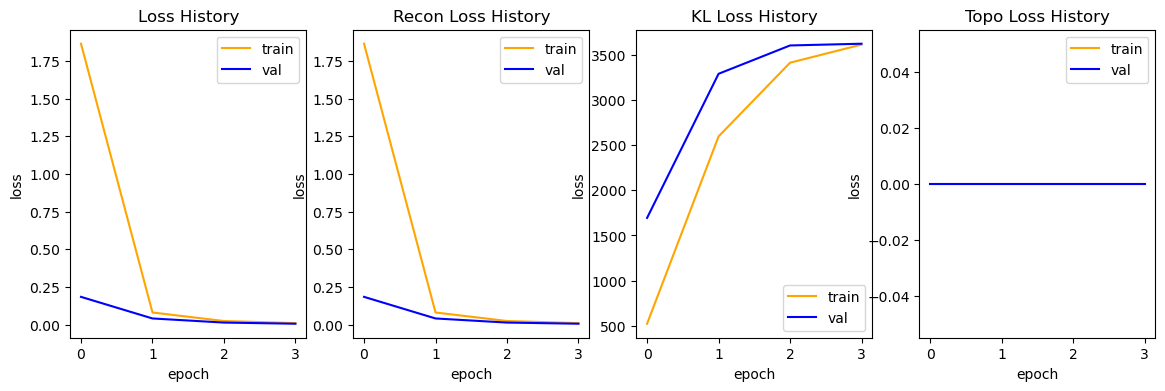

In [188]:
utils.show_training_history(history)

### Visualizing the latent space

latent vectors shape (1000, 2)


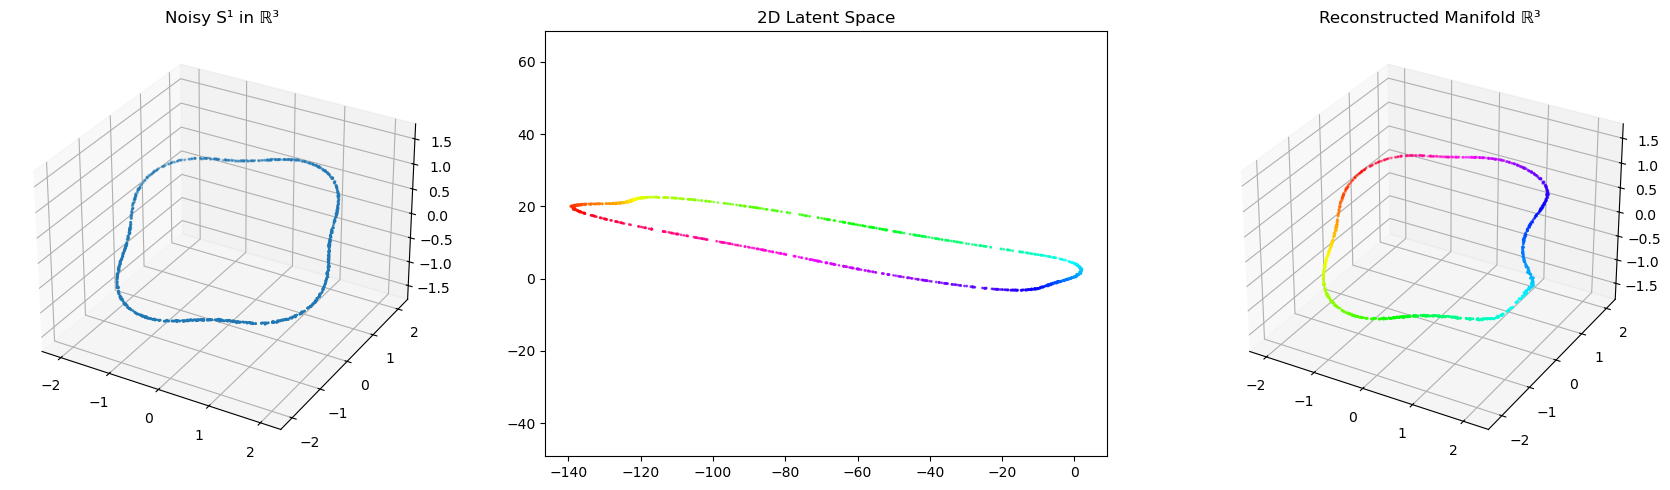

In [189]:
utils.plot_data_latents_recon(model, test_loader, "cpu", 6000)

### Plot reconstructed manifold

### Compute curvature error

In [190]:
#utils.curvature_compute_plot_euclidean(config=config, model=model)

Forwarding data through model...
Computing true curvature on latent vectors...
Starting actual computation...
Curvature computation finished.


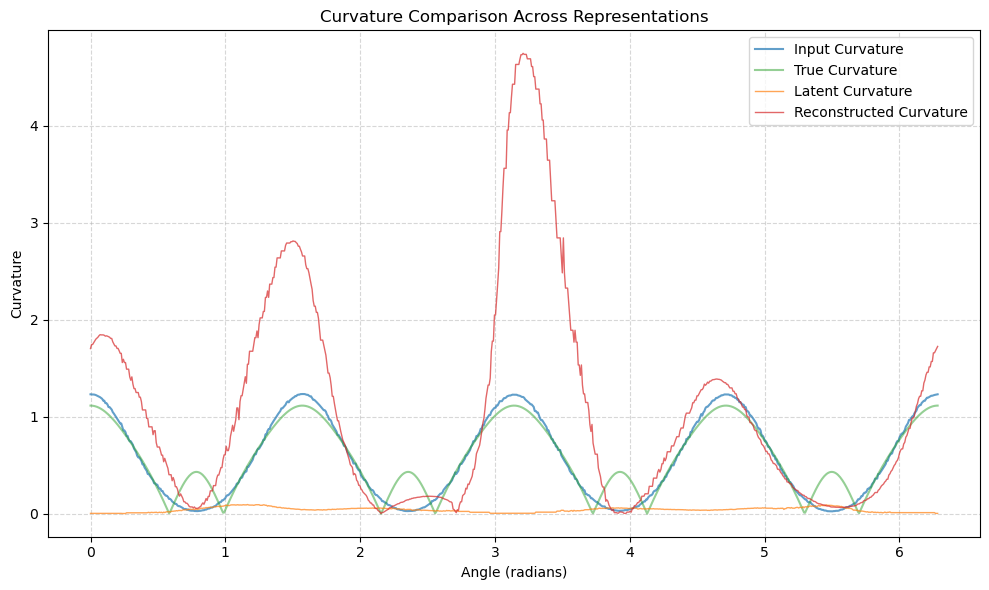

In [191]:
utils.plot_empiric_curvature(config=config, model=model)